# Buổi 3 — Dữ liệu thời gian

**Một câu:** trước khi đếm, gộp hay ghép bất cứ thứ gì theo thời gian, hãy đưa mọi cột giờ về **UTC có ghi múi giờ**.

Làm sai điều đó trên dữ liệu taxi New York, bạn sẽ "phát hiện" ba điều vô lý mà không dòng code nào báo lỗi: có một giờ
cả thành phố không ai đi taxi, New York nóng nhất lúc 8 giờ tối, và mưa làm giảm khách. Năm phần dưới lần lượt giải
thích từng điều.

## 0. Dữ liệu

**Bộ dữ liệu NYC Yellow Taxi Trip Records.** Cơ quan quản lý taxi New York (TLC) công bố **mọi chuyến taxi vàng**, mỗi tháng một tệp Parquet — định dạng
lưu bảng theo từng cột, có nén, đọc nhanh hơn CSV. Mỗi dòng là **một chuyến**: đón lúc nào, ở đâu, trả lúc nào, ở
đâu, đi bao xa, trả bao nhiêu tiền. Một tháng khoảng 3,5 triệu chuyến, 19 cột. Cột giờ **không ghi múi giờ** — từ
điển dữ liệu của TLC cũng không nói; ta sẽ phải tự tìm ra đó là giờ gì.

Nguồn: NYC Taxi & Limousine Commission, TLC Trip Record Data, Yellow Taxi 2024-03 (truy cập 2026-09-17); và 2 tệp cùng họ. Giấy phép NYC Open Data — không giới hạn sử dụng.

| Cột | Nghĩa |
|---|---|
| `tpep_pickup_datetime` | giờ **đón** khách (lúc đồng hồ tính tiền bật) |
| `tpep_dropoff_datetime` | giờ **trả** khách |
| `PULocationID`, `DOLocationID` | mã khu vực đón / trả (1–265), tra tên trong bảng khu vực |
| `passenger_count`, `trip_distance` | số khách, quãng đường (dặm) |
| `fare_amount`, `tip_amount`, `total_amount` | tiền cước, tiền boa, tổng tiền (USD) |

**Bộ dữ liệu Open-Meteo Historical Weather (ERA5).** Thời tiết **theo giờ** tại một điểm lưới giữa Manhattan, lấy từ dịch vụ Open-Meteo (dữ liệu tái phân tích
ERA5 của châu Âu). Tệp CSV có 3 dòng đầu là thông tin điểm lưới (toạ độ, độ cao, múi giờ), rồi mới tới bảng. Tệp được
tải với tuỳ chọn `timezone=UTC`, nên cột giờ là **giờ UTC** — khác với cột giờ của taxi.

Nguồn: Weather data by Open-Meteo.com (https://open-meteo.com/), mô hình ERA5; và 1 tệp cùng họ. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `time` | giờ đo, **UTC**, không ghi hậu tố múi giờ |
| `temperature_2m (°C)` | nhiệt độ ở độ cao 2 m |
| `precipitation (mm)`, `rain (mm)`, `snowfall (cm)` | tổng mưa + tuyết quy ra nước; riêng mưa; riêng tuyết, trong giờ đó |

Ô dưới tải dữ liệu (171 MB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [ ]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "nyc-tlc-yellow-2024-03": ("2d4cdc8fb96726cdd3803b13b02d2e61e71d45720aff0ebc693a8bdd1f249823", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/nyc-tlc-yellow-2024-03/yellow_tripdata_2024-03.parquet",
        "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-03.parquet",
    ]),
    "nyc-tlc-yellow-2024-11": ("5ef321876de5007a7c147a347389133fc94fd7ac28f82eb1d57d8f2cf05cfd3b", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/nyc-tlc-yellow-2024-11/yellow_tripdata_2024-11.parquet",
        "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-11.parquet",
    ]),
    "open-meteo-new-york-2024-03-11": ("fd75dc93e76dcd02fb2d8ec8e5491ff8c8f94616ede6dc5c54f2ef8cd287a75d", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/open-meteo-new-york-2024-03-11/open-meteo-new-york-2024-03-11-utc.csv",
        "https://archive-api.open-meteo.com/v1/archive?latitude=40.7128&longitude=-74.006&start_date=2024-03-01&end_date=2024-11-30&hourly=temperature_2m,precipitation,rain,snowfall&timezone=UTC&models=era5&format=csv",
    ]),
    "nyc-tlc-yellow-2024-01": ("c4d59da7bbc8abaeeeb1727947ee93d9891a71acb42854bd80db1571b2030510", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/nyc-tlc-yellow-2024-01/yellow_tripdata_2024-01.parquet",
        "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet",
    ]),
    "open-meteo-new-york-2024-01": ("117856cb5284ae37d680f254d3196feb9332373694573797ea6f65805d0aa569", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/open-meteo-new-york-2024-01/open-meteo-new-york-2024-01.csv",
        "https://archive-api.open-meteo.com/v1/archive?latitude=40.7128&longitude=-74.006&start_date=2024-01-01&end_date=2024-01-31&hourly=temperature_2m,precipitation,rain,snowfall&timezone=UTC&models=era5&format=csv",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

In [ ]:
import time

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

NY = "America/New_York"


def doc_chuyen(thang):
    df = pd.read_parquet(lay(f"nyc-tlc-yellow-2024-{thang}"),
                         columns=["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID"])
    dau = pd.Timestamp(f"2024-{thang}-01")
    return df[df["tpep_pickup_datetime"].between(dau, dau + pd.offsets.MonthBegin(1), inclusive="left")]


t3, t11 = doc_chuyen("03"), doc_chuyen("11")
print(f"tháng 3: {len(t3):,} chuyến | tháng 11: {len(t11):,} chuyến")
print("múi giờ của cột giờ đón:", t3["tpep_pickup_datetime"].dt.tz)

Múi giờ là `None`: cột giờ chỉ có con số, không nói đó là giờ ở đâu. Mọi rắc rối của buổi bắt đầu từ đây.

## 1. Một con số giờ chưa đủ để biết "khi nào"

**Vấn đề.** "8 giờ" ở New York là mấy giờ ở nơi khác? Còn tuỳ mùa.

> **UTC** · *Coordinated Universal Time*
>
> - **Là gì:** giờ phối hợp quốc tế — một đồng hồ chung cho cả thế giới, chạy đều, không bao giờ vặn theo mùa.
> - **Ví dụ:** 07:00 sáng ở Hà Nội là 00:00 UTC; cùng lúc đó ở New York (mùa hè) là 20:00 tối hôm trước.
> - **Để làm gì:** đặt mọi nguồn dữ liệu lên **một** trục thời gian để đếm, gộp, ghép cho đúng.

> **hậu tố Z** · *Z suffix, Zulu time*
>
> - **Là gì:** chữ Z ở cuối một giờ nghĩa là "giờ này tính theo UTC" — giống hệt viết `+00:00`.
> - **Ví dụ:** `07:30Z` = 07:30 UTC = 14:30 Hà Nội.
> - **Để làm gì:** nhìn là biết giờ đã ở UTC, không cần đoán.

> **offset (độ lệch múi giờ)** · *UTC offset*
>
> - **Là gì:** giờ địa phương lệch UTC bao nhiêu giờ. Giờ UTC = giờ địa phương − offset.
> - **Ví dụ:** Hà Nội +7 quanh năm: 14:00 Hà Nội = 07:00Z. New York mùa đông −5: 20:00 New York = 01:00Z hôm sau.
> - **Để làm gì:** là con số cần để đổi qua lại giữa giờ địa phương và UTC.

> **múi giờ, IANA** · *time zone, IANA Time Zone Database*
>
> - **Là gì:** múi giờ là tên một vùng dùng chung luật giờ, ví dụ `America/New_York`. IANA là tổ chức giữ bảng tra múi giờ mà mọi máy tính dùng.
> - **Ví dụ:** bảng IANA ghi: `America/New_York` đổi offset hai lần mỗi năm, vào ngày nào, lúc mấy giờ.
> - **Để làm gì:** dùng tên múi giờ (không dùng offset cố định) thì máy tự biết lúc nào là −5, lúc nào là −4.

> **giờ mùa hè (DST)** · *daylight saving time*
>
> - **Là gì:** một số nơi vặn đồng hồ nhanh 1 giờ vào mùa hè cho trời tối muộn, rồi vặn lại vào mùa thu.
> - **Ví dụ:** New York 2024: nhanh lên ngày 10/3 (mất giờ 02:xx), lùi lại ngày 3/11 (giờ 01:xx xảy ra hai lần).
> - **Để làm gì:** là nguồn gốc của giờ "không tồn tại" và giờ "lặp" — hai lỗi kinh điển của dữ liệu thời gian.
>
> 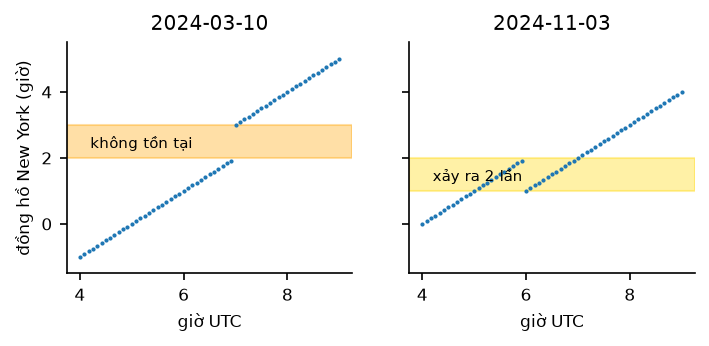

> **EST / EDT** · *Eastern Standard Time / Eastern Daylight Time*
>
> - **Là gì:** giờ chuẩn miền Đông nước Mỹ (UTC−5) và giờ mùa hè miền Đông (UTC−4).
> - **Ví dụ:** 00:00 EST = 05:00Z; 00:00 EDT = 04:00Z.
> - **Để làm gì:** cùng một con số giờ New York, EST hay EDT cho hai thời điểm UTC khác nhau một giờ.

> **naive / aware** · *naive / aware datetime*
>
> - **Là gì:** thời điểm không ghi múi giờ (naive) hoặc có ghi (aware).
> - **Ví dụ:** `2024-03-10 01:30` là naive; `2024-03-10 01:30-05:00` là aware.
> - **Để làm gì:** chỉ thời điểm aware mới chỉ đúng một khoảnh khắc; pandas từ chối ghép nhầm aware với naive.

**Lý do.** New York lệch UTC 5 giờ vào mùa đông (EST) và 4 giờ vào mùa hè (EDT), vì họ vặn đồng hồ hai lần mỗi năm:

- **10/3/2024**: 02:00 vặn lên 03:00 → giờ 02:xx **không tồn tại**.
- **3/11/2024**: 02:00 vặn lùi về 01:00 → giờ 01:xx **xảy ra hai lần**.

Đổi giờ: **UTC = giờ New York + 5** (mùa đông) hoặc **+ 4** (mùa hè). pandas làm việc này bằng hai bước:
`tz_localize(NY)` gắn múi giờ, `tz_convert("UTC")` đổi sang UTC.

**Kết quả.**

In [ ]:
for ngay, gio in [("2024-03-10", "01:30"), ("2024-03-10", "02:30"), ("2024-03-10", "03:30"), ("2024-11-03", "01:30")]:
    ket_qua = []
    for mua_he in (True, False):
        try:
            ket_qua.append(pd.Timestamp(f"{ngay} {gio}").tz_localize(NY, ambiguous=mua_he).tz_convert("UTC").strftime("%H:%MZ"))
        except Exception:
            pass
    print(f"{ngay} {gio} New York → UTC:", " hoặc ".join(sorted(set(ket_qua))) or "KHÔNG TỒN TẠI")

**Bài học.** Một giờ New York không kèm múi giờ có thể ứng với **một, không, hoặc hai** thời điểm thật. Giờ UTC thì
luôn đúng một.

## 2. Đếm trên giờ không múi giờ tạo ra giờ 0 chuyến giả và giờ gấp đôi

**Vấn đề.** Đếm số chuyến mỗi giờ ngay trên cột giờ naive (không múi giờ) thì sao?

> **NaN, NaT** · *Not a Number, Not a Time*
>
> - **Là gì:** ô "không biết" của pandas: NaN cho số (Not a Number), NaT cho thời gian (Not a Time).
> - **Ví dụ:** nhiệt độ lúc 01:00 không đo được → NaN, khác hẳn 0 độ; giờ 01:30 ngày 3/11 không biết EDT hay EST → NaT.
> - **Để làm gì:** ghi thật thà "không biết" thay vì bịa một con số — mô hình và người đọc sẽ không bị lừa.

**Lý do.** Nếu cột là giờ New York, ngày 10/3 sẽ có một giờ **trống** (giờ đó không tồn tại), ngày 3/11 có một giờ
**gấp đôi** (hai giờ thật mang cùng một con số 01:xx).

**Kết quả.**

In [ ]:
def dem_naive(chuyen):
    return chuyen.set_index("tpep_pickup_datetime").resample("h").size()


for ngay, chuyen in [("2024-03-10", t3), ("2024-11-03", t11)]:
    print(ngay, "đếm naive:", {f"{k:%H:%M}": int(v) for k, v in dem_naive(chuyen)[f"{ngay} 00:00":f"{ngay} 03:00"].items()})
print("01:00 Chủ nhật tuần sau (10/11):", int(dem_naive(t11)["2024-11-10 01:00"]), "chuyến")

Giờ 02:00 ngày 10/3 có **0 chuyến**; giờ 01:00 ngày 3/11 có **9.869 chuyến**, gần gấp đôi tuần sau (5.318). Thêm một
dấu vết: tính thời lượng chuyến bằng cách trừ thẳng hai giờ naive thì ngày 3/11 có khách "xuống xe trước khi lên".

In [ ]:
am = t11["tpep_dropoff_datetime"] < t11["tpep_pickup_datetime"]
gio_lap = (t11["tpep_pickup_datetime"].dt.date == pd.Timestamp("2024-11-03").date()) & (t11["tpep_pickup_datetime"].dt.hour == 1)
print(f"chuyến 'trả trước khi đón' cả tháng 11: {am.sum():,} — trong đó rơi vào giờ lặp 01:xx ngày 3/11: {(am & gio_lap).sum():,}")

**Bài học.** Cột giờ taxi là giờ New York naive. Phải gắn múi giờ New York, đổi UTC, **rồi** mới đếm. Chuyến rơi vào
giờ lặp không thể biết là lần đầu hay lần hai — ghi "không biết" (NaN), đừng đoán.

## 3. Gộp theo giờ: số lượng thì cộng, số đo thì trung bình

**Vấn đề.** Chuyến taxi đến lúc nào cũng được; mô hình cần mỗi giờ một con số. Gộp thế nào?

> **chuỗi đều / chuỗi không đều** · *regular / irregular time series*
>
> - **Là gì:** chuỗi đều: các mốc cách nhau bằng nhau. Không đều: lúc dày lúc thưa.
> - **Ví dụ:** chuyến taxi lúc 00:10, 00:50, 02:20 là không đều; số chuyến mỗi giờ 00:00, 01:00, 02:00 là đều.
> - **Để làm gì:** mô hình dự báo cần chuỗi đều — phải gộp dữ liệu sự kiện về từng khoảng bằng nhau.
>
> 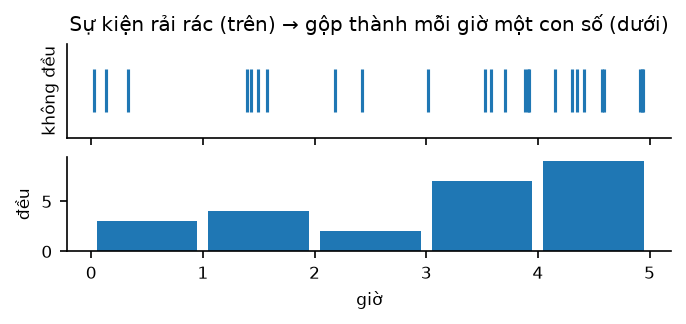

> **tần suất, resample** · *frequency, resampling*
>
> - **Là gì:** tần suất là khoảng cách giữa hai mốc liền nhau (`h` giờ, `D` ngày, `W` tuần). `resample` đổi tần suất bằng cách gộp.
> - **Ví dụ:** `s.resample("h").sum()` cộng mọi chuyến trong mỗi giờ thành một con số.
> - **Để làm gì:** biến dữ liệu thô thành chuỗi đều đúng độ chi tiết của quyết định.

> **closed, label** · *interval closure, bin label*
>
> - **Là gì:** khi gộp: đầu nào của khoảng được tính vào (`closed`), và khoảng mang tên mốc đầu hay mốc cuối (`label`).
> - **Ví dụ:** khoảng [9:00, 10:00) tên "9:00" (đóng trái, nhãn trái): có chuyến 9:00 và 9:40, không có chuyến 10:00.
> - **Để làm gì:** biết con số thuộc khoảng nào — nhãn đầu khoảng mà dùng sớm là vô tình dùng dữ liệu chưa xảy ra.
>
> 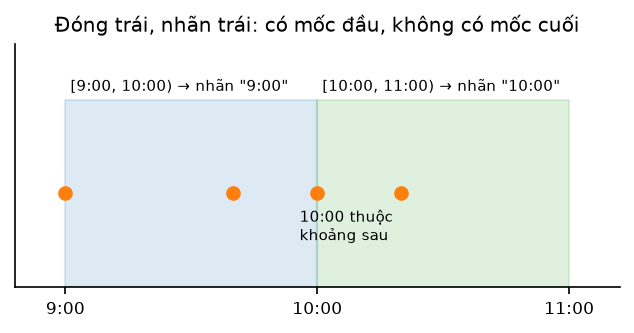

**Lý do.** Ba câu phải trả lời:

1. **Mốc nào thuộc giờ nào?** Mặc định pandas làm tròn **xuống** đầu giờ: 9:40 → 9:00, còn 10:00 là 10:00.
2. **Cộng hay trung bình?** Số lượng (số chuyến) thì cộng. Số đo (nhiệt độ) thì trung bình — cộng 60 lần đo ra "1.500 độ".
3. **Giờ trống ghi gì?** Đếm sự kiện: **0** (không có chuyến). Số đo: **NaN** (không đo, khác "0 độ").

**Kết quả.** Ba sự kiện lúc 00:10, 00:50, 02:20; giờ 01:00 trống:

In [ ]:
s = pd.Series([1.0, 2.0, 5.0], index=pd.to_datetime(["2024-01-01 00:10", "2024-01-01 00:50", "2024-01-01 02:20"]))
print("cộng        :", s.resample("h").sum().tolist(), "  ← giờ trống = 0")
print("trung bình  :", s.resample("h").mean().tolist(), "← giờ trống = NaN")

**Bài học.** Chọn cách gộp theo **bản chất** của con số, không theo thói quen. Tháng 3 đếm trên UTC có **743** giờ,
không phải 744 — ngày 10/3 chỉ dài 23 giờ.

## 4. Ghép hai bảng lệch múi giờ: sai mà không báo lỗi

**Vấn đề.** Ghép số chuyến (giờ New York) với thời tiết (giờ UTC) theo con số giờ, dòng "15:00" nối dòng "15:00".

> **ghép as-of (merge_asof)** · *as-of join*
>
> - **Là gì:** ghép mỗi dòng với giá trị **gần nhất đã có** ở trước (hoặc đúng) thời điểm của dòng đó.
> - **Ví dụ:** đơn hàng lúc 10:07 lấy giá cập nhật lúc 10:05, không lấy giá lúc 10:10.
> - **Để làm gì:** ghép hai nguồn không cùng nhịp mà không nhìn trộm tương lai.
>
> 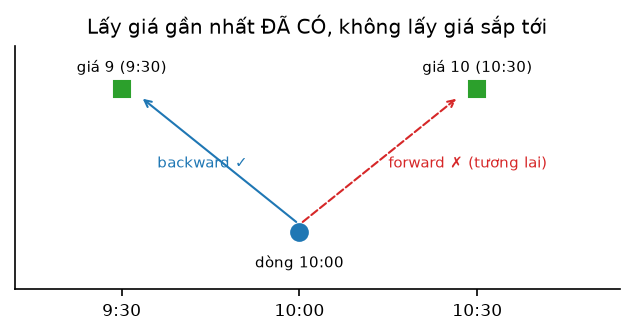

**Lý do.** Cả hai cột đều naive nên pandas không biết chúng khác nhau. Tháng 3 lệch 4 giờ, nên thời tiết bị dời 4 giờ.
Phép thử rẻ nhất: **giờ nóng nhất trong ngày** — ai cũng biết buổi chiều nóng hơn buổi tối.

**Kết quả.**

In [ ]:
tt = pd.read_csv(lay("open-meteo-new-york-2024-03-11"), skiprows=3)
tt.columns = ["time", "nhiet_do", "mua", "mua_rao", "tuyet"]
tt["ds"] = pd.to_datetime(tt["time"])                                  # giờ UTC, nhưng naive

# SAI: giờ New York naive ghép với giờ UTC naive
sai = dem_naive(t3).rename("y").rename_axis("ds").reset_index().merge(tt, on="ds")
# ĐÚNG: cả hai về UTC có múi giờ
utc = t3["tpep_pickup_datetime"].dt.tz_localize(NY, ambiguous="NaT", nonexistent="NaT").dt.tz_convert("UTC")
dem_dung = utc.dt.floor("h").value_counts().rename("y").rename_axis("ds").reset_index()
dung = dem_dung.merge(tt.assign(ds=tt["ds"].dt.tz_localize("UTC")), on="ds")

nong_sai = sai.groupby(sai["ds"].dt.hour)["nhiet_do"].mean()
nong_dung = dung.groupby(dung["ds"].dt.tz_convert(NY).dt.hour)["nhiet_do"].mean()
print("giờ nóng nhất — ghép sai:", nong_sai.idxmax(), "h | ghép đúng:", nong_dung.idxmax(), "h")

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(nong_dung, "o-", label="ghép đúng")
ax.plot(nong_sai, "o-", color="tab:orange", label="ghép sai")
ax.set(xlabel="giờ trong ngày (New York)", ylabel="°C", title="Ghép sai: New York 'nóng nhất lúc 8 giờ tối'")
ax.legend(fontsize=8)
plt.show()

Ghép sai đẩy cả đường nhiệt độ đi 4 giờ: đỉnh lúc 20h thay vì 16h. Lỗi này còn **đổi dấu** kết luận thật: tương quan
mưa – số chuyến (sau khi trừ nhịp tuần) âm khi ghép sai, dương khi ghép đúng:

In [ ]:
def tuong_quan_mua(ghep, gio):
    lech = ghep["y"] - ghep.groupby([gio.dt.dayofweek, gio.dt.hour])["y"].transform("mean")   # bỏ nhịp tuần
    return np.corrcoef(ghep["mua"], lech)[0, 1]


print(f"mưa – số chuyến: ghép sai {tuong_quan_mua(sai, sai['ds']):+.2f} | ghép đúng {tuong_quan_mua(dung, dung['ds'].dt.tz_convert(NY)):+.2f}")

Một trường hợp hay gặp: bảng bên phải không có đúng mốc của bên trái (giá chỉ ghi khi thay đổi). `merge_asof` ghép mỗi
dòng với dòng **gần nhất theo thời gian**; hướng tìm quyết định có rò rỉ tương lai hay không:

In [ ]:
trai = pd.DataFrame({"t": pd.to_datetime(["2024-01-01 10:00"])})
phai = pd.DataFrame({"t": pd.to_datetime(["2024-01-01 09:30", "2024-01-01 10:30"]), "gia": [9, 10]})
print("dòng 10:00 — backward (mặc định, nhìn về quá khứ):", pd.merge_asof(trai, phai, on="t")["gia"][0])
print("dòng 10:00 — forward  (lấy giá 10:30 CHƯA xảy ra):", pd.merge_asof(trai, phai, on="t", direction="forward")["gia"][0])

**Bài học.** Đưa **mọi** nguồn về UTC có múi giờ rồi mới ghép — khi đó pandas sẽ từ chối ghép nhầm cột có múi giờ với
cột không có. Luôn kiểm lại bằng một điều hiển nhiên (giờ nóng nhất). Ghép "gần nhất" thì chỉ nhìn về quá khứ.

## 5. Nhiều chuỗi: dạng dài trên một lưới chung

**Vấn đề.** Cần một chuỗi theo giờ cho **từng khu vực** đón khách — tháng 3 có 259 khu vực. Lưu thế nào?

> **định dạng dài / định dạng rộng** · *long / wide format*
>
> - **Là gì:** dạng dài: mỗi dòng một bộ (chuỗi, mốc, giá trị). Dạng rộng: mỗi chuỗi một cột.
> - **Ví dụ:** 2 khu vực × 3 giờ: dạng dài 6 dòng × 3 cột; dạng rộng 3 dòng × 2 cột số.
> - **Để làm gì:** dạng dài thêm chuỗi chỉ thêm dòng — gọn cho hàng trăm chuỗi và là dạng các thư viện dự báo nhận vào.

> **unique_id, ds, y** · *series id, datestamp, target value*
>
> - **Là gì:** ba cột của dạng dài: tên chuỗi, thời điểm, giá trị cần dự báo.
> - **Ví dụ:** ("161", 2024-03-01 05:00Z, 412): khu vực 161 có 412 chuyến trong giờ bắt đầu 05:00Z.
> - **Để làm gì:** một quy ước chung để mọi buổi sau đọc dữ liệu giống nhau.

> **backtest** · *backtesting*
>
> - **Là gì:** giả vờ đứng ở nhiều mốc cắt trong quá khứ, dự báo, rồi so với cái đã thật sự xảy ra.
> - **Ví dụ:** đứng ở 4 thứ Hai của tháng 3, mỗi lần dự báo 24 giờ tới, rồi chấm.
> - **Để làm gì:** chấm mô hình trung thực — và là lý do mọi chuỗi phải nằm trên cùng một lưới mốc.
>
> 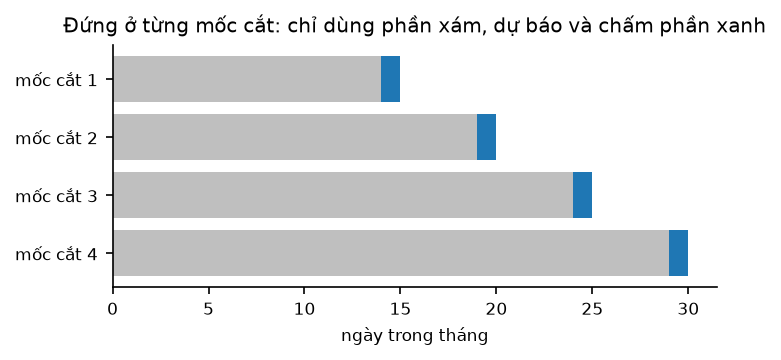

**Lý do.** Dùng dạng dài `unique_id, ds, y`, và mọi chuỗi phải có **cùng một danh sách mốc**: khu vực vắng lúc 3 giờ sáng vẫn cần dòng
"0 chuyến", để sau này backtest mọi chuỗi ở cùng một mốc cắt.

**Kết quả.** Gắn múi giờ → đổi UTC → làm tròn xuống giờ → đếm → trải lên lưới 743 giờ của tháng 3, giờ trống ghi 0:

In [ ]:
utc_kv = t3.assign(ds=utc.dt.floor("h")).dropna(subset=["ds"])
dem_kv = utc_kv.groupby(["PULocationID", "ds"]).size()
luoi = pd.date_range("2024-03-01 05:00", "2024-04-01 04:00", freq="h", tz="UTC", inclusive="left")   # [đầu, cuối)
day_du = pd.MultiIndex.from_product([dem_kv.index.levels[0], luoi], names=["unique_id", "ds"])
dai = dem_kv.reindex(day_du, fill_value=0).rename("y").reset_index()

print(f"{len(dai):,} dòng = {dai['unique_id'].nunique()} khu vực × {len(luoi)} giờ | tổng chuyến {dai['y'].sum():,}")
print(f"tỷ lệ ô bằng 0: {(dai['y'] == 0).mean():.1%}")
dai.head(3)

**192.437 dòng**, không mất chuyến nào, và **53,7%** số ô bằng 0 — đa số khu vực rất thưa khách, vài khu (Midtown,
sân bay JFK) thì rất đông.

**Bài học.** Dữ liệu thời gian "sạch" = dạng dài `unique_id, ds, y`, `ds` là UTC, đủ mốc trên một lưới chung, không trùng.

## 6. pandas, polars, DuckDB: nhanh như nhau, nhưng xử lý giờ lặp khác nhau

**Vấn đề.** Ngoài pandas còn **polars** (chạy "lười": xem cả chuỗi lệnh rồi mới chạy, chỉ đọc cột cần) và **DuckDB** (chạy
SQL thẳng trên tệp). Chọn cái nào?

**Lý do.** Với vài triệu dòng, cả ba đều dưới một giây — tốc độ không phải vấn đề chính. Vấn đề là mỗi công cụ **im lặng
làm một kiểu khác nhau** với giờ lặp ngày 3/11.

**Kết quả.** Đếm theo giờ UTC, 00:00–04:00 giờ New York ngày 3/11:

In [ ]:
TEP11 = str(lay("nyc-tlc-yellow-2024-11"))
G = "tpep_pickup_datetime"
bd = time.perf_counter()
p = (pl.scan_parquet(TEP11)
     .filter(pl.col(G).is_between(pl.datetime(2024, 11, 3, 0), pl.datetime(2024, 11, 3, 4), closed="left"))
     .select(pl.col(G).dt.replace_time_zone(NY, ambiguous="null").dt.convert_time_zone("UTC").dt.truncate("1h"))
     .group_by(G).len().sort(G).collect())
print(f"polars ({time.perf_counter() - bd:.2f} s):", {str(k)[11:16] if k else "null": v for k, v in p.iter_rows()})

duckdb.sql("SET TimeZone = 'UTC'")                        # không để DuckDB lấy múi giờ của máy
q = duckdb.sql(f"SELECT date_trunc('hour', timezone('{NY}', {G})) AS g, count(*) FROM read_parquet('{TEP11}') "
               f"WHERE {G} >= '2024-11-03 00:00' AND {G} < '2024-11-03 04:00' GROUP BY 1 ORDER BY 1").fetchall()
print("DuckDB:", {f"{k:%H:%M}": v for k, v in q})

polars gom 9.869 chuyến mơ hồ vào nhóm `null` — thấy ngay có vấn đề. DuckDB lặng lẽ coi tất cả là giờ mùa đông, dồn
vào 06:00 và **làm mất** 05:00 — bảng trông sạch nhất nhưng sai nhất. (Và nếu quên `SET TimeZone`, DuckDB lấy múi giờ của
máy, nên cùng câu SQL ra kết quả khác nhau trên hai máy.)

**Bài học.** Công cụ nào cũng được, miễn là bạn **biết** nó xử lý giờ không tồn tại và giờ lặp thế nào — và kiểm lại.

## 7. Bài tập về nhà — đáp số

**Bài 1 — Đếm theo giờ bằng polars**, so từng giờ với cách pandas (phần 2–5), tháng 3 và tháng 11:

In [ ]:
def dem_polars(thang):
    dau, cuoi = pl.datetime(2024, int(thang), 1), pl.datetime(2024, int(thang) + 1, 1)
    return (pl.scan_parquet(str(lay(f"nyc-tlc-yellow-2024-{thang}")))
            .filter(pl.col(G).is_between(dau, cuoi, closed="left"))
            .select(pl.col(G).dt.replace_time_zone(NY, ambiguous="null", non_existent="null")
                    .dt.convert_time_zone("UTC").dt.truncate("1h").alias("ds"))
            .drop_nulls().group_by("ds").len().collect().to_pandas().set_index("ds")["len"])


for thang, chuyen in [("03", t3), ("11", t11)]:
    pd_ = chuyen["tpep_pickup_datetime"].dt.tz_localize(NY, ambiguous="NaT", nonexistent="NaT").dropna() \
        .dt.tz_convert("UTC").dt.floor("h").value_counts()
    so = pd.concat([pd_.rename("pandas"), dem_polars(thang).rename("polars")], axis=1, sort=True)
    print(f"tháng {thang}: {len(so)} giờ, số giờ lệch nhau: {(so['pandas'] != so['polars']).sum()}")

Không giờ nào lệch: hai công cụ cho cùng kết quả khi cùng xử lý múi giờ đúng cách.

**Bài 2 — Mùa đông lệch mấy giờ?** Tháng 1 New York là giờ mùa đông (UTC−5). Dự đoán trước: ghép sai sẽ đẩy giờ nóng
nhất đi 5 giờ.

In [ ]:
t1 = doc_chuyen("01")
tt1 = pd.read_csv(lay("open-meteo-new-york-2024-01"), skiprows=3)
tt1.columns = ["time", "nhiet_do", "mua", "mua_rao", "tuyet"]
tt1["ds"] = pd.to_datetime(tt1["time"])
sai1 = dem_naive(t1).rename("y").rename_axis("ds").reset_index().merge(tt1, on="ds")
u1 = t1["tpep_pickup_datetime"].dt.tz_localize(NY, ambiguous="NaT", nonexistent="NaT").dt.tz_convert("UTC")
dung1 = u1.dt.floor("h").value_counts().rename("y").rename_axis("ds").reset_index() \
    .merge(tt1.assign(ds=tt1["ds"].dt.tz_localize("UTC")), on="ds")
g_sai = sai1.groupby(sai1["ds"].dt.hour)["nhiet_do"].mean().idxmax()
g_dung = dung1.groupby(dung1["ds"].dt.tz_convert(NY).dt.hour)["nhiet_do"].mean().idxmax()
print(f"tháng 1 — giờ nóng nhất: ghép sai {g_sai}h, ghép đúng {g_dung}h → lệch {g_sai - g_dung} giờ")

Tháng 1 lệch 5 giờ, tháng 3 lệch 4: độ lệch đổi theo mùa, nên không thể "sửa" bản ghép sai bằng cách dời cố định một
số giờ. Cách duy nhất đúng quanh năm là đưa cả hai về UTC.

## Tự kiểm

- [ ] Đổi được 01:30 ngày 3/11/2024 New York sang UTC (có hai đáp án — vì sao?).
- [ ] Giải thích giờ 0 chuyến ngày 10/3 và giờ 9.869 chuyến ngày 3/11.
- [ ] Nói được khi nào gộp bằng cộng, khi nào trung bình; giờ trống là 0 hay NaN.
- [ ] Giải thích vì sao ghép lệch làm "nóng nhất lúc 20h" và đổi dấu tương quan mưa.